# XGBoost — Gradient Boosted Trees

---

## Table of Contents
1. [Boosting — The Core Idea](#1-boosting)
2. [Gradient Boosting — Learning in Function Space](#2-gradient-boosting)
3. [The XGBoost Objective — Second-Order Taylor Expansion](#3-xgboost-objective)
4. [Optimal Leaf Weights & Split Gain](#4-optimal-leaf-weights--split-gain)
5. [Regularisation & Tree Complexity](#5-regularisation)
6. [Practical Mechanics — Shrinkage, Subsampling, Early Stopping](#6-practical-mechanics)
7. [XGBoost vs Random Forest — When to Use Which](#7-xgboost-vs-random-forest)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#ccc',
    'xtick.color': '#888', 'ytick.color': '#888', 'text.color': '#eee',
    'grid.color': '#2a2a2a', 'grid.linewidth': 0.8,
    'font.family': 'monospace', 'axes.titlesize': 12, 'axes.labelsize': 11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'
WHITE  = '#eeeeee'

---
## 1. Boosting — The Core Idea

Boosting builds an ensemble **sequentially**: each new model corrects the errors of the previous ones.

The final prediction is an **additive model**:
$$\hat{y}(x) = \sum_{t=1}^T f_t(x)$$

where each $f_t$ is a weak learner (typically a shallow tree). The key is the word *additive* — at step $t$ we have:
$$\hat{y}^{(t)}(x) = \hat{y}^{(t-1)}(x) + f_t(x)$$

We choose $f_t$ to **reduce the loss** of the current ensemble. That is:
$$f_t = \arg\min_{f} \sum_{i=1}^n \ell\!\left(y_i,\, \hat{y}^{(t-1)}(x_i) + f(x_i)\right)$$

**Bagging vs Boosting**:
- **Bagging** (Random Forest): trees built in parallel, on bootstrap samples, independently. Reduces variance.
- **Boosting**: trees built sequentially, each correcting the residuals of the previous. Reduces both bias and variance — but can overfit if run too long.

### AdaBoost — The Original Boosting Algorithm

AdaBoost fits each new learner on a **reweighted** dataset: misclassified samples get higher weight, so the next tree focuses on them. The final model is a weighted vote:
$$\hat{y}(x) = \text{sign}\!\left(\sum_t \alpha_t f_t(x)\right)$$
where $\alpha_t = \frac{1}{2}\ln\frac{1-\epsilon_t}{\epsilon_t}$ and $\epsilon_t$ is the weighted error of tree $t$.

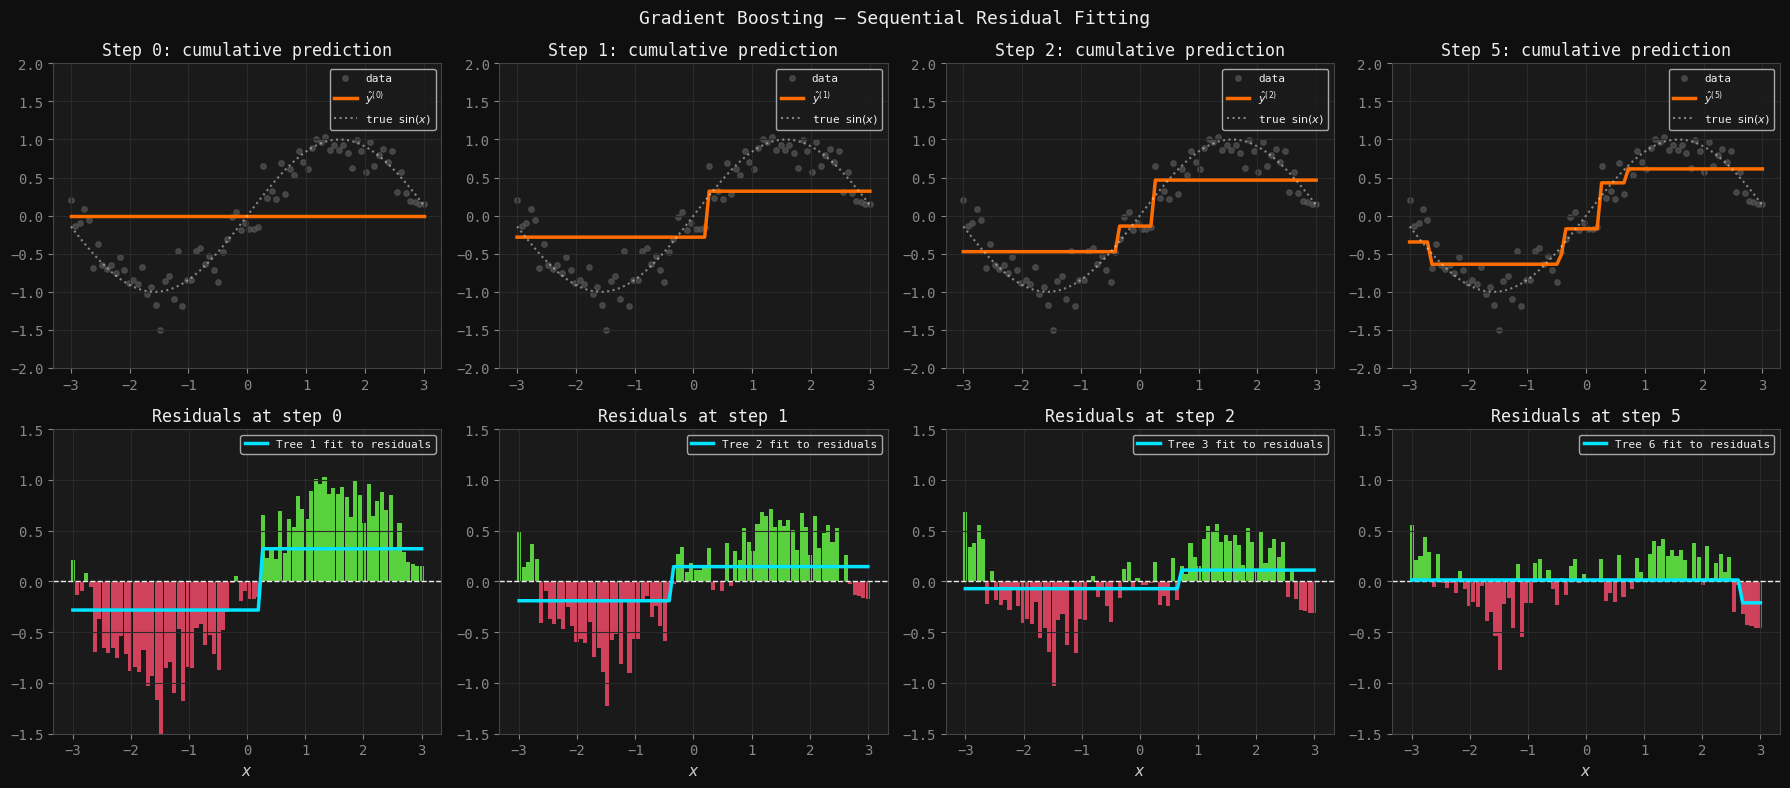

In [2]:
np.random.seed(0)
x_boost = np.linspace(-3, 3, 80)
y_boost = np.sin(x_boost) + np.random.normal(0, 0.2, 80)

# Manual gradient boosting with stumps (depth=1 trees)
def gradient_boost_demo(x, y, n_trees=6, lr=0.5):
    x_2d = x.reshape(-1, 1)
    F = np.zeros(len(x))  # initial prediction = 0
    trees = []
    residuals_history = [y.copy()]
    predictions_history = [F.copy()]
    for t in range(n_trees):
        residuals = y - F
        tree = DecisionTreeRegressor(max_depth=1)
        tree.fit(x_2d, residuals)
        update = lr * tree.predict(x_2d)
        F = F + update
        trees.append(tree)
        residuals_history.append(y - F)
        predictions_history.append(F.copy())
    return trees, residuals_history, predictions_history

trees, resid_hist, pred_hist = gradient_boost_demo(x_boost, y_boost, n_trees=6, lr=0.5)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Gradient Boosting — Sequential Residual Fitting', fontsize=13)

steps_to_show = [0, 1, 2, 5]
for col, step in enumerate(steps_to_show):
    ax_top = axes[0][col]
    ax_bot = axes[1][col]

    # Top: current prediction vs data
    ax_top.scatter(x_boost, y_boost, color='#555', s=15, alpha=0.7, label='data')
    ax_top.plot(x_boost, pred_hist[step], color=ORANGE, lw=2.5,
                label=f'$\\hat{{y}}^{{({step})}}$')
    ax_top.plot(x_boost, np.sin(x_boost), color=WHITE, lw=1.5,
                linestyle=':', alpha=0.5, label='true $\\sin(x)$')
    ax_top.set_title(f'Step {step}: cumulative prediction')
    ax_top.legend(fontsize=8); ax_top.grid(True)
    ax_top.set_ylim(-2, 2)

    # Bottom: current residuals
    resid = resid_hist[step]
    ax_bot.bar(x_boost, resid, width=0.07,
               color=[GREEN if r > 0 else RED for r in resid], alpha=0.8)
    ax_bot.axhline(0, color=WHITE, lw=1, linestyle='--')
    if step < len(trees):
        stump_pred = 0.5 * trees[step].predict(x_boost.reshape(-1,1))
        ax_bot.plot(x_boost, stump_pred, color=ACCENT, lw=2.5,
                    label=f'Tree {step+1} fit to residuals')
        ax_bot.legend(fontsize=8)
    ax_bot.set_title(f'Residuals at step {step}')
    ax_bot.set_xlabel('$x$'); ax_bot.grid(True)
    ax_bot.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('img/xgb01_boosting.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Gradient Boosting — Learning in Function Space

Gradient boosting interprets boosting as **gradient descent in function space**.

Let $\mathcal{L} = \sum_i \ell(y_i, \hat{y}_i)$. The **negative gradient** of the loss w.r.t. the current predictions:
$$r_i^{(t)} = -\frac{\partial \ell(y_i, \hat{y}^{(t-1)}(x_i))}{\partial \hat{y}^{(t-1)}(x_i)}$$

These $r_i^{(t)}$ are called **pseudo-residuals**. We fit tree $f_t$ to these pseudo-residuals — as if doing regression on them.

**Why this works**: fitting $f_t$ to $r^{(t)}$ is equivalent to taking a step in the direction of steepest descent in the space of functions. The analogy with gradient descent:

| Gradient Descent (params) | Gradient Boosting (functions) |
|---|---|
| $\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$ | $F \leftarrow F + \eta f_t$, where $f_t \approx -\nabla_F \mathcal{L}$ |
| Step in parameter space | Step in function space |

**Pseudo-residuals for common losses**:

| Loss | $\ell(y, \hat{y})$ | Pseudo-residual $r_i$ |
|------|------|------|
| MSE | $\frac{1}{2}(y-\hat{y})^2$ | $y_i - \hat{y}_i$ (true residuals) |
| MAE | $|y - \hat{y}|$ | $\text{sign}(y_i - \hat{y}_i)$ |
| Log-loss | $-y\log\hat{p} - (1-y)\log(1-\hat{p})$ | $y_i - \hat{p}_i$ |
| Huber | smooth approximation to MAE | clipped residuals |

For MSE the pseudo-residuals are exactly the true residuals — this is why MSE gradient boosting is often described simply as "fitting trees to residuals".

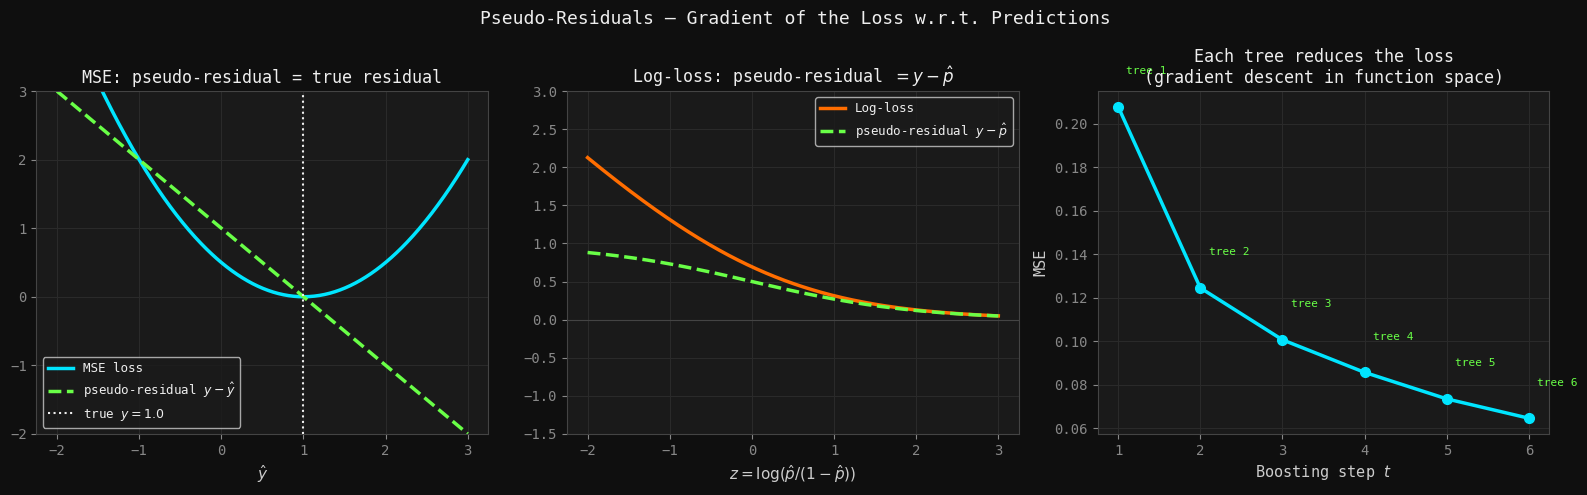

In [3]:
# Pseudo-residual derivation for different losses
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pseudo-Residuals — Gradient of the Loss w.r.t. Predictions', fontsize=13)

y_true_ex = 1.0
y_hat_range = np.linspace(-2, 3, 400)

# MSE pseudo-residuals
ax = axes[0]
mse_loss = 0.5 * (y_true_ex - y_hat_range)**2
mse_grad = -(y_true_ex - y_hat_range)  # = y_hat - y
mse_resid = y_true_ex - y_hat_range    # pseudo-residual = -grad
ax.plot(y_hat_range, mse_loss,  color=ACCENT,  lw=2.5, label='MSE loss')
ax.plot(y_hat_range, mse_resid, color=GREEN,   lw=2.5, linestyle='--', label='pseudo-residual $y - \\hat{y}$')
ax.axvline(y_true_ex, color=WHITE, lw=1.5, linestyle=':', label=f'true $y={y_true_ex}$')
ax.set_xlabel('$\\hat{y}$'); ax.set_title('MSE: pseudo-residual = true residual')
ax.legend(fontsize=9); ax.grid(True); ax.set_ylim(-2, 3)

# Log-loss pseudo-residuals
ax = axes[1]
y_true_cls = 1
p_hat = 1 / (1 + np.exp(-y_hat_range))
logloss = -(y_true_cls * np.log(p_hat + 1e-9) + (1-y_true_cls) * np.log(1-p_hat+1e-9))
resid_log = y_true_cls - p_hat
ax.plot(y_hat_range, logloss,   color=ORANGE,  lw=2.5, label='Log-loss')
ax.plot(y_hat_range, resid_log, color=GREEN,    lw=2.5, linestyle='--', label='pseudo-residual $y - \\hat{p}$')
ax.axhline(0, color='#444', lw=0.8)
ax.set_xlabel('$z = \\log(\\hat{p}/(1-\\hat{p}))$')
ax.set_title('Log-loss: pseudo-residual $= y - \\hat{p}$')
ax.legend(fontsize=9); ax.grid(True); ax.set_ylim(-1.5, 3)

# Gradient boosting = gradient descent in function space
ax = axes[2]
steps = np.arange(1, 7)
losses_step = [np.mean((y_boost - pred_hist[s])**2) for s in steps]
ax.plot(steps, losses_step, color=ACCENT, lw=2.5, marker='o', ms=7)
for i, (s, l) in enumerate(zip(steps, losses_step)):
    ax.annotate(f'tree {s}', xy=(s, l), xytext=(s+0.1, l+0.015),
                color=GREEN, fontsize=8)
ax.set_xlabel('Boosting step $t$'); ax.set_ylabel('MSE')
ax.set_title('Each tree reduces the loss\n(gradient descent in function space)')
ax.grid(True)

plt.tight_layout()
plt.savefig('img/xgb02_gradient_boosting.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. The XGBoost Objective — Second-Order Taylor Expansion

This is what separates XGBoost from vanilla gradient boosting. Instead of using only the first-order gradient (pseudo-residuals), XGBoost uses a **second-order Taylor expansion** of the loss.

At step $t$, define:
- $\hat{y}_i^{(t-1)}$ — current prediction for sample $i$
- $f_t(x_i)$ — the new tree's contribution

Expand the loss around the current prediction:
$$\ell(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) \approx \ell(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2$$

where:
$$g_i = \frac{\partial \ell(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}} \quad \text{(first derivative — gradient)}$$
$$h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2} \quad \text{(second derivative — Hessian)}$$

Dropping terms constant in $f_t$, the objective to minimise at step $t$ is:
$$\mathcal{L}^{(t)} = \sum_{i=1}^n \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)$$

where $\Omega(f_t)$ is a regularisation term on the tree (see Section 5).

**Why second order?** The Hessian $h_i$ provides curvature information — it tells us how quickly the gradient is changing. This allows XGBoost to take better-calibrated steps, especially in regions where the loss surface is very curved. The analogy is Newton's method vs gradient descent: Newton uses curvature and converges faster.

**$(g_i, h_i)$ for common losses**:

| Loss | $g_i$ | $h_i$ |
|------|-------|-------|
| MSE $\frac{1}{2}(y-\hat{y})^2$ | $\hat{y}_i - y_i$ | $1$ |
| Log-loss | $\hat{p}_i - y_i$ | $\hat{p}_i(1-\hat{p}_i)$ |
| Poisson $\hat{y} - y\log\hat{y}$ | $\hat{y}_i - y_i$ | $\hat{y}_i$ |

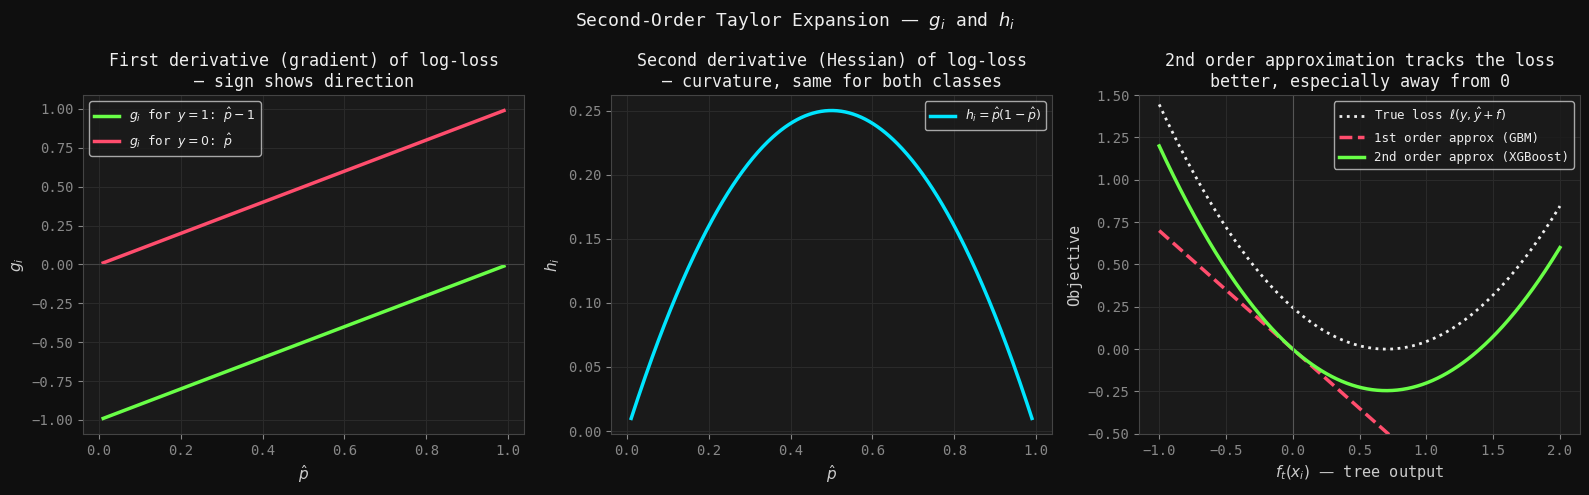

In [4]:
# g and h for log-loss as a function of predicted probability
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Second-Order Taylor Expansion — $g_i$ and $h_i$', fontsize=13)

p_range = np.linspace(0.01, 0.99, 400)

# For y=1
g_y1 = p_range - 1       # = p_hat - y
h_y1 = p_range * (1 - p_range)
# For y=0
g_y0 = p_range - 0
h_y0 = p_range * (1 - p_range)  # same hessian

ax = axes[0]
ax.plot(p_range, g_y1, color=GREEN,  lw=2.5, label='$g_i$ for $y=1$: $\\hat{p}-1$')
ax.plot(p_range, g_y0, color=RED,    lw=2.5, label='$g_i$ for $y=0$: $\\hat{p}$')
ax.axhline(0, color='#444', lw=0.8)
ax.set_xlabel('$\\hat{p}$'); ax.set_ylabel('$g_i$')
ax.set_title('First derivative (gradient) of log-loss\n— sign shows direction')
ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
ax.plot(p_range, h_y1, color=ACCENT, lw=2.5,
        label='$h_i = \\hat{p}(1-\\hat{p})$')
ax.set_xlabel('$\\hat{p}$'); ax.set_ylabel('$h_i$')
ax.set_title('Second derivative (Hessian) of log-loss\n— curvature, same for both classes')
ax.legend(fontsize=9); ax.grid(True)

# Why 2nd order: compare first-order vs second-order approximation
ax = axes[2]
y_ex = 1.0
hat_y_curr = 0.3  # current prediction
grid = np.linspace(-1, 2, 400)
true_loss    = 0.5 * (y_ex - (hat_y_curr + grid))**2
g = hat_y_curr - y_ex  # MSE gradient
h = 1.0                 # MSE hessian
first_order  = g * grid
second_order = g * grid + 0.5 * h * grid**2
ax.plot(grid, true_loss,    color=WHITE,  lw=2,   linestyle=':', label='True loss $\\ell(y, \\hat{y}+f)$')
ax.plot(grid, first_order,  color=RED,    lw=2.5, linestyle='--', label='1st order approx (GBM)')
ax.plot(grid, second_order, color=GREEN,  lw=2.5, label='2nd order approx (XGBoost)')
ax.axvline(0, color='#555', lw=0.8)
ax.set_xlabel('$f_t(x_i)$ — tree output'); ax.set_ylabel('Objective')
ax.set_title('2nd order approximation tracks the loss\nbetter, especially away from 0')
ax.legend(fontsize=9); ax.grid(True); ax.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.savefig('img/xgb03_taylor.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Optimal Leaf Weights & Split Gain

Assume the tree structure is fixed (the partition of samples into leaves). Let $I_j = \{i : x_i \in \text{leaf}_j\}$ be the set of samples in leaf $j$, and $w_j$ be the weight (prediction) at leaf $j$.

The objective becomes:
$$\mathcal{L}^{(t)} = \sum_{j=1}^J \left[ \left(\sum_{i \in I_j} g_i\right) w_j + \frac{1}{2}\left(\sum_{i \in I_j} h_i + \lambda\right) w_j^2 \right] + \gamma J$$

This is a **sum of independent quadratics** in each $w_j$. Minimising each separately:
$$\frac{\partial}{\partial w_j} \mathcal{L}^{(t)} = \left(\sum_{i \in I_j} g_i\right) + \left(\sum_{i \in I_j} h_i + \lambda\right) w_j = 0$$

$$\boxed{w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda} = -\frac{G_j}{H_j + \lambda}}$$

where $G_j = \sum_{i \in I_j} g_i$ and $H_j = \sum_{i \in I_j} h_i$.

Substituting $w_j^*$ back:
$$\mathcal{L}^{(t)*} = -\frac{1}{2}\sum_{j=1}^J \frac{G_j^2}{H_j + \lambda} + \gamma J$$

### Split Gain

For a candidate split of leaf $j$ into left ($L$) and right ($R$):
$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

XGBoost only makes the split if $\text{Gain} > 0$. The $\gamma$ term acts as a **minimum gain threshold** — it prunes splits that don't improve the objective enough to justify the extra leaf.

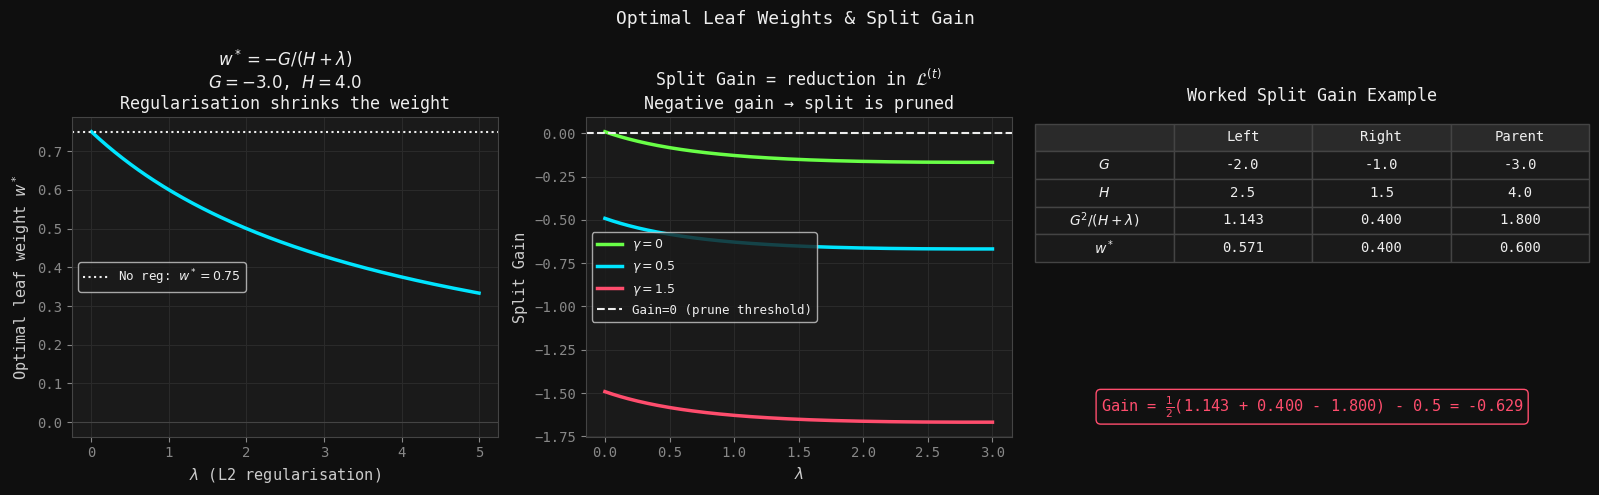

In [5]:
# Visualise optimal leaf weights and split gain
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Optimal Leaf Weights & Split Gain', fontsize=13)

# Optimal weight formula
ax = axes[0]
lambda_range = np.linspace(0, 5, 200)
G = -3.0  # sum of gradients in a leaf
H = 4.0   # sum of hessians
w_opt = -G / (H + lambda_range)
ax.plot(lambda_range, w_opt, color=ACCENT, lw=2.5)
ax.axhline(-G/H, color=WHITE, lw=1.5, linestyle=':', label=f'No reg: $w^* = {-G/H:.2f}$')
ax.axhline(0, color='#444', lw=0.8)
ax.set_xlabel('$\\lambda$ (L2 regularisation)')
ax.set_ylabel('Optimal leaf weight $w^*$')
ax.set_title(f'$w^* = -G/(H+\\lambda)$\n$G={G}$, $H={H}$\nRegularisation shrinks the weight')
ax.legend(fontsize=9); ax.grid(True)

# Split gain for different lambda and gamma
ax = axes[1]
G_L, H_L = -2.0, 2.5
G_R, H_R = -1.0, 1.5
G_P, H_P = G_L+G_R, H_L+H_R
lambda_sg = np.linspace(0, 3, 200)
for gamma, color, label in [(0.0, GREEN, '$\\gamma=0$'), (0.5, ACCENT, '$\\gamma=0.5$'), (1.5, RED, '$\\gamma=1.5$')]:
    gain = 0.5*(G_L**2/(H_L+lambda_sg) + G_R**2/(H_R+lambda_sg) - G_P**2/(H_P+lambda_sg)) - gamma
    ax.plot(lambda_sg, gain, color=color, lw=2.5, label=label)
ax.axhline(0, color=WHITE, lw=1.5, linestyle='--', label='Gain=0 (prune threshold)')
ax.fill_between(lambda_sg, 0, color=GREEN, alpha=0.05)
ax.set_xlabel('$\\lambda$'); ax.set_ylabel('Split Gain')
ax.set_title('Split Gain = reduction in $\\mathcal{L}^{(t)}$\nNegative gain → split is pruned')
ax.legend(fontsize=9); ax.grid(True)

# Numerical worked example
ax = axes[2]
ax.axis('off')
ax.set_title('Worked Split Gain Example', pad=12)
lam, gam = 1.0, 0.5
GL, HL = -2.0, 2.5
GR, HR = -1.0, 1.5
GP, HP = GL+GR, HL+HR
score_L = GL**2 / (HL + lam)
score_R = GR**2 / (HR + lam)
score_P = GP**2 / (HP + lam)
gain_val = 0.5*(score_L + score_R - score_P) - gam
rows = [
    ['', 'Left', 'Right', 'Parent'],
    ['$G$',   f'{GL}', f'{GR}', f'{GP}'],
    ['$H$',   f'{HL}', f'{HR}', f'{HP}'],
    ['$G^2/(H+\\lambda)$', f'{score_L:.3f}', f'{score_R:.3f}', f'{score_P:.3f}'],
    ['$w^*$', f'{-GL/(HL+lam):.3f}', f'{-GR/(HR+lam):.3f}', f'{-GP/(HP+lam):.3f}'],
]
tbl = ax.table(cellText=rows[1:], colLabels=rows[0], loc='upper center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.3, 2.0)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a1a' if r > 0 else '#2a2a2a')
    cell.set_edgecolor('#444'); cell.set_text_props(color='#eee')
ax.text(0.5, 0.08,
        f'Gain = $\\frac{{1}}{{2}}$({score_L:.3f} + {score_R:.3f} - {score_P:.3f}) - {gam} = {gain_val:.3f}',
        transform=ax.transAxes, ha='center', color=GREEN if gain_val > 0 else RED,
        fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#111', edgecolor=GREEN if gain_val>0 else RED))

plt.tight_layout()
plt.savefig('img/xgb04_leaf_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Regularisation & Tree Complexity

XGBoost's regularisation term on the tree $f_t$ with $J$ leaves and weights $w_1, \ldots, w_J$:

$$\Omega(f_t) = \gamma J + \frac{\lambda}{2}\sum_{j=1}^J w_j^2$$

- $\gamma$ — **minimum loss reduction** required to make a split. Acts like pre-pruning.
- $\lambda$ — **L2 regularisation** on leaf weights. Shrinks weights, reduces overfitting.
- $\alpha$ — **L1 regularisation** on leaf weights (also available). Drives some weights to zero.

**Effect of $\lambda$ on the optimal weight**:
$$w_j^* = -\frac{G_j}{H_j + \lambda}$$

When $\lambda \to \infty$: $w_j^* \to 0$ — total shrinkage.
When $\lambda = 0$: $w_j^* = -G_j/H_j$ — pure Newton step.

**Effect of $\gamma$ on splits**: Gain $< \gamma$ → the split is refused. This directly controls tree depth — higher $\gamma$ results in shallower trees.

### Additional XGBoost Hyperparameters

| Parameter | Effect |
|-----------|--------|
| `max_depth` | Max tree depth — controls complexity |
| `min_child_weight` | Min sum of $h_i$ in a leaf ($\approx$ min samples) — prevents small, noisy leaves |
| `subsample` | Fraction of training samples used per tree (stochastic boosting) |
| `colsample_bytree` | Fraction of features sampled per tree (like Random Forest) |
| `eta` (learning rate) | Shrinkage factor applied to each tree's weights |

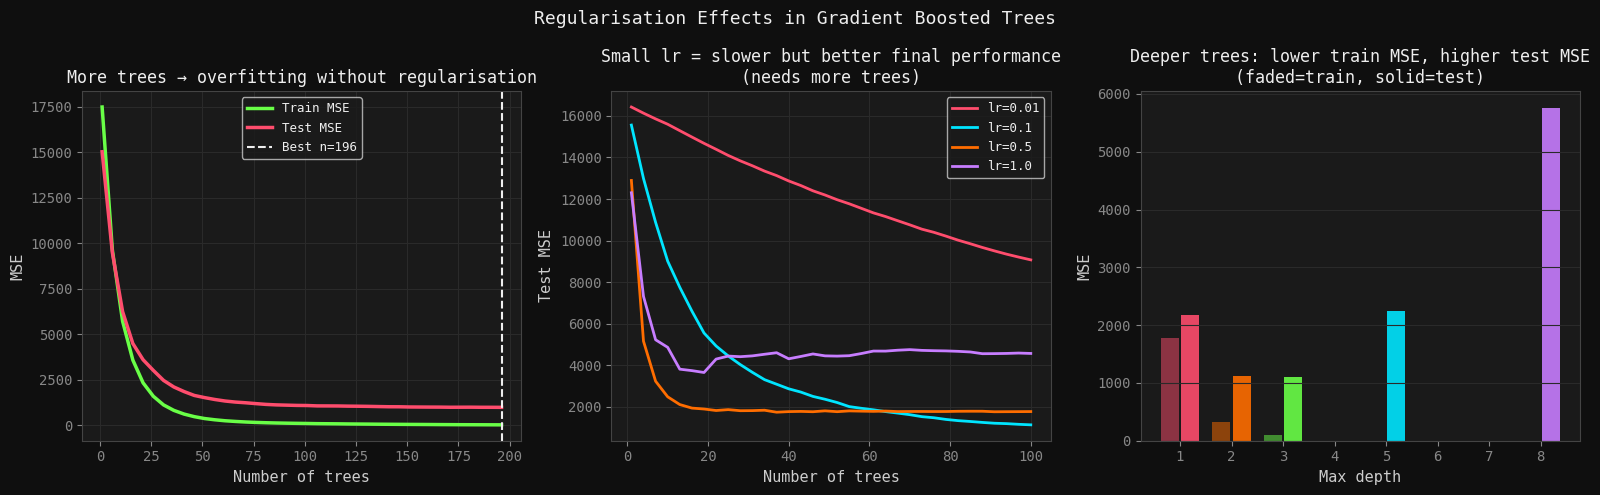

In [6]:
np.random.seed(7)
X_reg_xgb, y_reg_xgb = make_regression(n_samples=300, n_features=10,
                                         n_informative=5, noise=15, random_state=7)
X_tr_x, X_te_x, y_tr_x, y_te_x = train_test_split(X_reg_xgb, y_reg_xgb, test_size=0.25, random_state=0)

# Use sklearn GBM as XGBoost proxy
from sklearn.ensemble import GradientBoostingRegressor

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Regularisation Effects in Gradient Boosted Trees', fontsize=13)

# Effect of n_estimators (overfitting if too many)
ax = axes[0]
n_trees_list = range(1, 201, 5)
train_mse, test_mse = [], []
for n in n_trees_list:
    gbm = GradientBoostingRegressor(n_estimators=n, max_depth=3,
                                     learning_rate=0.1, random_state=0)
    gbm.fit(X_tr_x, y_tr_x)
    train_mse.append(np.mean((gbm.predict(X_tr_x) - y_tr_x)**2))
    test_mse.append(np.mean((gbm.predict(X_te_x) - y_te_x)**2))
ax.plot(list(n_trees_list), train_mse, color=GREEN,  lw=2.5, label='Train MSE')
ax.plot(list(n_trees_list), test_mse,  color=RED,    lw=2.5, label='Test MSE')
best_n = list(n_trees_list)[np.argmin(test_mse)]
ax.axvline(best_n, color=WHITE, lw=1.5, linestyle='--', label=f'Best n={best_n}')
ax.set_xlabel('Number of trees'); ax.set_ylabel('MSE')
ax.set_title('More trees → overfitting without regularisation')
ax.legend(fontsize=9); ax.grid(True)

# Effect of learning rate
ax = axes[1]
for lr, color in [(0.01, RED), (0.1, ACCENT), (0.5, ORANGE), (1.0, PURPLE)]:
    te_mse_lr = []
    for n in range(1, 101, 3):
        gbm = GradientBoostingRegressor(n_estimators=n, learning_rate=lr,
                                         max_depth=2, random_state=0)
        gbm.fit(X_tr_x, y_tr_x)
        te_mse_lr.append(np.mean((gbm.predict(X_te_x) - y_te_x)**2))
    ax.plot(range(1,101,3), te_mse_lr, color=color, lw=2, label=f'lr={lr}')
ax.set_xlabel('Number of trees'); ax.set_ylabel('Test MSE')
ax.set_title('Small lr = slower but better final performance\n(needs more trees)')
ax.legend(fontsize=9); ax.grid(True)

# max_depth effect
ax = axes[2]
for depth, color in [(1, RED), (2, ORANGE), (3, GREEN), (5, ACCENT), (8, PURPLE)]:
    gbm_d = GradientBoostingRegressor(n_estimators=100, max_depth=depth,
                                       learning_rate=0.1, random_state=0)
    gbm_d.fit(X_tr_x, y_tr_x)
    tr = np.mean((gbm_d.predict(X_tr_x) - y_tr_x)**2)
    te = np.mean((gbm_d.predict(X_te_x) - y_te_x)**2)
    ax.bar(depth - 0.2, tr, 0.35, color=color, alpha=0.5, label=f'depth={depth} train')
    ax.bar(depth + 0.2, te, 0.35, color=color, alpha=0.9)
ax.set_xlabel('Max depth')
ax.set_ylabel('MSE')
ax.set_title('Deeper trees: lower train MSE, higher test MSE\n(faded=train, solid=test)')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('img/xgb05_regularisation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Practical Mechanics — Shrinkage, Subsampling, Early Stopping

### Shrinkage (Learning Rate)

Each tree's contribution is scaled by $\eta \in (0,1]$:
$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot f_t(x)$$

Smaller $\eta$ → each tree has less influence → need more trees. In exchange, the model generalises better. The intuition: shrinkage prevents any single tree from dominating, keeping the ensemble flexible enough to be corrected by subsequent trees.

A common guideline: **set $\eta = 0.01$–$0.1$ and tune the number of trees with early stopping**.

### Stochastic Gradient Boosting

At each step, randomly sample:
- A fraction `subsample` of training rows (row subsampling)
- A fraction `colsample_bytree` of features (column subsampling)

This adds randomness similar to Random Forest, which:
- Decorrelates trees (reduces variance)
- Makes training faster
- Provides an implicit regularisation

### Early Stopping

Monitor a validation set metric after each tree. Stop when the metric has not improved for `early_stopping_rounds` consecutive trees. This automatically finds the optimal number of trees without a grid search.

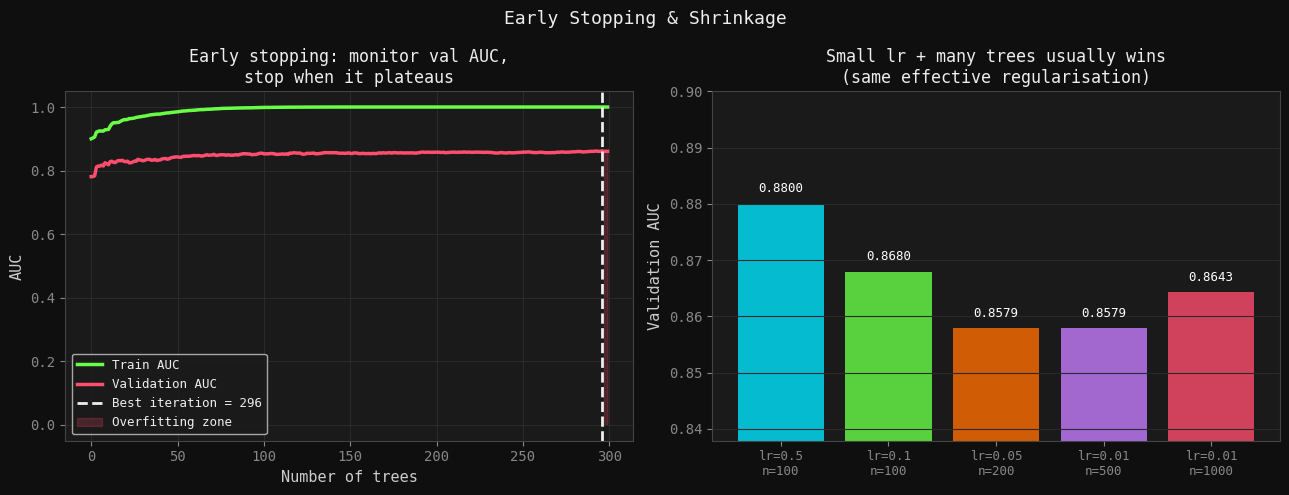

In [7]:
# Early stopping simulation
np.random.seed(9)
X_es, y_es = make_classification(n_samples=500, n_features=15,
                                   n_informative=7, random_state=9)
X_tr_es, X_val_es, y_tr_es, y_val_es = train_test_split(X_es, y_es, test_size=0.2, random_state=0)

# Staged predictions from GBM
gbm_es = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                     max_depth=3, random_state=0)
gbm_es.fit(X_tr_es, y_tr_es)

train_auc, val_auc = [], []
for pred_tr, pred_val in zip(
    gbm_es.staged_predict_proba(X_tr_es),
    gbm_es.staged_predict_proba(X_val_es)
):
    train_auc.append(roc_auc_score(y_tr_es, pred_tr[:,1]))
    val_auc.append(roc_auc_score(y_val_es, pred_val[:,1]))

best_iter = np.argmax(val_auc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Early Stopping & Shrinkage', fontsize=13)

ax = axes[0]
ax.plot(train_auc, color=GREEN,  lw=2.5, label='Train AUC')
ax.plot(val_auc,   color=RED,    lw=2.5, label='Validation AUC')
ax.axvline(best_iter, color=WHITE, lw=2, linestyle='--',
           label=f'Best iteration = {best_iter}')
ax.fill_between(range(len(val_auc)), val_auc,
                where=np.array(range(len(val_auc))) > best_iter,
                alpha=0.2, color=RED, label='Overfitting zone')
ax.set_xlabel('Number of trees'); ax.set_ylabel('AUC')
ax.set_title('Early stopping: monitor val AUC,\nstop when it plateaus')
ax.legend(fontsize=9); ax.grid(True)

# Shrinkage: final performance vs lr * n_trees product
ax = axes[1]
configs = [
    (0.5, 100, ACCENT),
    (0.1, 100, GREEN),
    (0.05, 200, ORANGE),
    (0.01, 500, PURPLE),
    (0.01, 1000, RED),
]
names_sh, val_aucs_sh = [], []
for lr, n, color in configs:
    gbm_sh = GradientBoostingClassifier(n_estimators=n, learning_rate=lr,
                                         max_depth=3, random_state=0)
    gbm_sh.fit(X_tr_es, y_tr_es)
    auc_sh = roc_auc_score(y_val_es, gbm_sh.predict_proba(X_val_es)[:,1])
    names_sh.append(f'lr={lr}\nn={n}')
    val_aucs_sh.append(auc_sh)
    bars = ax.bar(len(val_aucs_sh)-1, auc_sh, color=color, alpha=0.8)
ax.set_xticks(range(len(names_sh))); ax.set_xticklabels(names_sh, fontsize=9)
ax.set_ylabel('Validation AUC')
ax.set_title('Small lr + many trees usually wins\n(same effective regularisation)')
ax.set_ylim(min(val_aucs_sh)-0.02, max(val_aucs_sh)+0.02)
ax.grid(True, axis='y')
for i, v in enumerate(val_aucs_sh):
    ax.text(i, v+0.002, f'{v:.4f}', ha='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('img/xgb06_early_stopping.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. XGBoost vs Random Forest — When to Use Which

| | Random Forest | XGBoost |
|---|---|---|
| **How trees are built** | In parallel, independently | Sequentially, each corrects the previous |
| **What it reduces** | Variance (averaging) | Bias + Variance (residual fitting) |
| **Overfitting risk** | Low (hard to overfit) | Higher (can overfit if tuning is poor) |
| **Hyperparameter sensitivity** | Low | High |
| **Training speed** | Parallelisable — fast | Sequential — slower per tree |
| **Inference speed** | Moderate | Faster (trees are shallower) |
| **Tabular data performance** | Strong baseline | Often best-in-class |
| **Noisy data** | More robust | Can overfit noise |
| **Missing values** | Needs imputation | Handles natively |
| **Interpretability** | Feature importances | Feature importances + SHAP |

**Practical guidance**:
- Start with **Random Forest** as a baseline — it almost always works well with minimal tuning
- Switch to **XGBoost** (or LightGBM, CatBoost) when you need to squeeze out the last percentage points
- **Always use early stopping** with XGBoost — it makes hyperparameter tuning dramatically easier
- On **small datasets** ($n < 1000$): tree-based models often outperform neural networks
- On **large datasets with many features**: LightGBM is usually faster than XGBoost due to histogram-based splitting

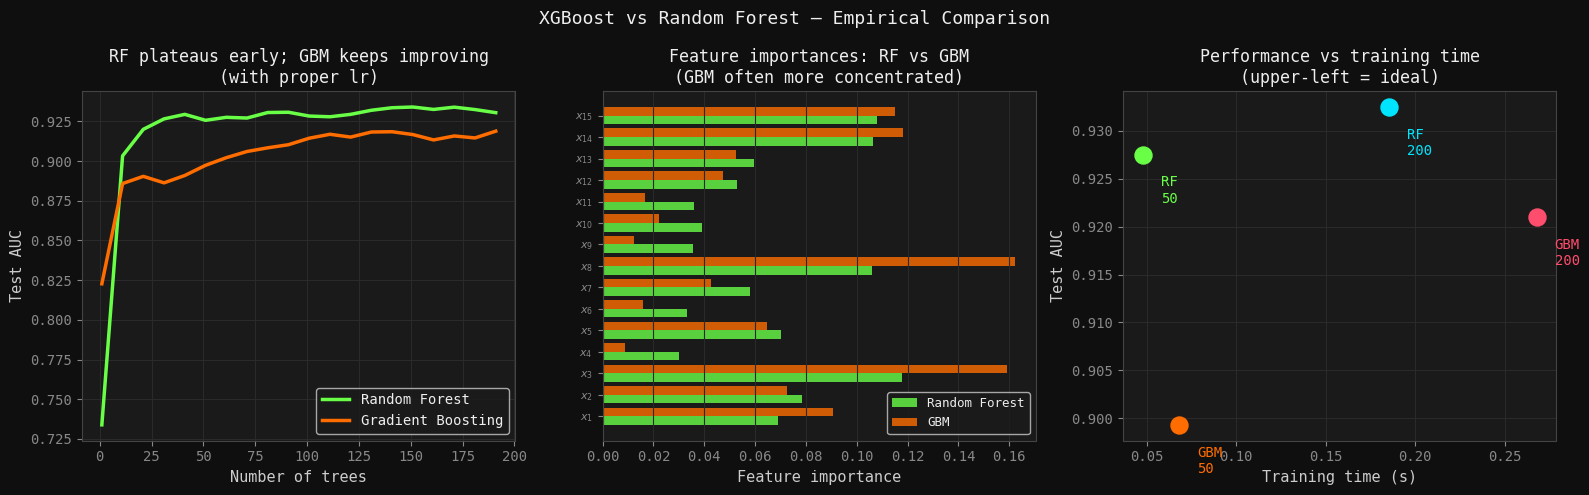

In [8]:
np.random.seed(11)
X_cmp, y_cmp = make_classification(n_samples=600, n_features=15,
                                     n_informative=8, random_state=11)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cmp, y_cmp, test_size=0.25, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost vs Random Forest — Empirical Comparison', fontsize=13)

# AUC vs n_estimators
ax = axes[0]
n_range = range(1, 201, 10)
rf_aucs, gbm_aucs = [], []
for n in n_range:
    rf  = RandomForestClassifier(n_estimators=n, random_state=0).fit(X_tr_c, y_tr_c)
    gbm = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1,
                                      max_depth=3, random_state=0).fit(X_tr_c, y_tr_c)
    rf_aucs.append(roc_auc_score(y_te_c,  rf.predict_proba(X_te_c)[:,1]))
    gbm_aucs.append(roc_auc_score(y_te_c, gbm.predict_proba(X_te_c)[:,1]))
ax.plot(list(n_range), rf_aucs,  color=GREEN,  lw=2.5, label='Random Forest')
ax.plot(list(n_range), gbm_aucs, color=ORANGE, lw=2.5, label='Gradient Boosting')
ax.set_xlabel('Number of trees'); ax.set_ylabel('Test AUC')
ax.set_title('RF plateaus early; GBM keeps improving\n(with proper lr)')
ax.legend(fontsize=10); ax.grid(True)

# Feature importance: RF vs GBM
ax = axes[1]
rf_final  = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_tr_c, y_tr_c)
gbm_final = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                        max_depth=3, random_state=0).fit(X_tr_c, y_tr_c)
feature_idx = np.arange(X_cmp.shape[1])
rf_imp  = rf_final.feature_importances_
gbm_imp = gbm_final.feature_importances_
width   = 0.4
ax.barh(feature_idx - 0.2, rf_imp,  width, color=GREEN,  alpha=0.8, label='Random Forest')
ax.barh(feature_idx + 0.2, gbm_imp, width, color=ORANGE, alpha=0.8, label='GBM')
ax.set_yticks(feature_idx)
ax.set_yticklabels([f'$x_{{{i+1}}}$' for i in feature_idx], fontsize=8)
ax.set_xlabel('Feature importance')
ax.set_title('Feature importances: RF vs GBM\n(GBM often more concentrated)')
ax.legend(fontsize=9); ax.grid(True, axis='x')

# Training time vs performance
ax = axes[2]
import time
results = []
for name, model, color in [
    ('RF\n50',   RandomForestClassifier(n_estimators=50, random_state=0), GREEN),
    ('RF\n200',  RandomForestClassifier(n_estimators=200, random_state=0), ACCENT),
    ('GBM\n50',  GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=0), ORANGE),
    ('GBM\n200', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=0), RED),
]:
    t0 = time.time()
    model.fit(X_tr_c, y_tr_c)
    t1 = time.time()
    auc = roc_auc_score(y_te_c, model.predict_proba(X_te_c)[:,1])
    results.append((name, t1-t0, auc, color))

for i, (name, t, auc_v, color) in enumerate(results):
    ax.scatter(t, auc_v, color=color, s=150, zorder=5)
    ax.annotate(name, (t, auc_v), xytext=(t+0.01, auc_v-0.005), fontsize=10, color=color)
ax.set_xlabel('Training time (s)')
ax.set_ylabel('Test AUC')
ax.set_title('Performance vs training time\n(upper-left = ideal)')
ax.grid(True)

plt.tight_layout()
plt.savefig('img/xgb07_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Key Takeaways

1. Boosting builds an **additive model sequentially** — each tree corrects the errors of the previous ensemble. The final model is $\hat{y} = \sum_t \eta f_t(x)$.
2. **Gradient boosting = gradient descent in function space** — pseudo-residuals $r_i = -\partial\ell/\partial\hat{y}_i$ are the negative gradient, and each tree is a step in the direction of steepest descent.
3. **XGBoost uses a second-order Taylor expansion** of the loss, incorporating curvature $h_i$. This allows closed-form optimal leaf weights: $w_j^* = -G_j/(H_j+\lambda)$.
4. The **split gain formula** $\frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{G_P^2}{H_P+\lambda}\right]-\gamma$ decides whether to make a split — negative gain means the split is refused.
5. $\gamma$ controls minimum gain per split (depth), $\lambda$ shrinks leaf weights (L2), $\eta$ scales each tree's contribution (shrinkage).
6. **Early stopping** on a validation set is the most important practical technique — it automatically finds the optimal number of trees.
7. Random Forest is the robust baseline; XGBoost wins when carefully tuned on clean tabular data. Always start simple.

---
*Previous: [`05_decision_trees.ipynb`](./05_decision_trees.ipynb) · Next: [`07_kmeans.ipynb`](./07_kmeans.ipynb)*